# Installations / import / création session spark

In [1]:
# Installation de modules
%pip install numpy matplotlib networkx pyspark tqdm PySide6 scipy nomkl ipykernel

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.1 MB/s eta 0:00:00
  Created wheel for nomkl: filename=nomkl-0.0.3-py3-none-any.whl size=987 sha256=c21d88c998d4ae861d25c7f1027f1d690e66a8a2569eff40928f8a67b0a2847b
  Stored in directory: /root/.cache/pip/wheels/aa/7a/e7/ba216b063728c71411d8e9a4bc0323ee37a247f6d2e0461298
Successfully built nomkl


In [2]:
!git clone https://github.com/operiana/CCF-Algorithm-Implementation-with-PySpark.git

Cloning into 'CCF-Algorithm-Implementation-with-PySpark'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 54 (delta 16), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 22.00 MiB | 18.12 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [3]:
# Pour décompresser l'archive .gz contenant le fichier texte
!gunzip /content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt.gz

In [4]:
# Dataset Friendster (1.8 milliards d'arêtes)
!wget https://snap.stanford.edu/data/bigdata/communities/com-friendster.ungraph.txt.gz

--2026-03-01 16:21:52--  https://snap.stanford.edu/data/bigdata/communities/com-friendster.ungraph.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9371322431 (8.7G) [application/x-gzip]
Saving to: ‘com-friendster.ungraph.txt.gz’

com-friendster.ungr 100%[===================>]   8.73G  42.8MB/s    in 3m 30s  

2026-03-01 16:25:22 (42.5 MB/s) - ‘com-friendster.ungraph.txt.gz’ saved [9371322431/9371322431]



In [5]:
# Import des modules
from pyspark import SparkConf
from pyspark.context import SparkContext
from pyspark import RDD

from typing import Iterable, Generator
from matplotlib.colors import CSS4_COLORS

import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import pyspark
import time
import os

%matplotlib inline

In [6]:
# Creation de session PySpark
sc = SparkContext.getOrCreate(SparkConf().setMaster("local[*]"))

# Rappel des algorithmes

Soit $G=(V,E)$ le graphe dont l'on cherche à extraire les composantes connexes.
L'algorithme $\texttt{CCF}$ peut-être décrit de la manière suivante :

1. $\texttt{INPUT}$ / Liste des arêtes du graphe $EL := \{(u, v)\}_{(u,v) \in E(G)}$ avec $u, v$ deux noeuds de $G$ représentés par leur identifiant, i.e. $u, v \in \llbracket 1, |V(G)| \rrbracket$.
2. $\texttt{RÉPÈTER JUSQU'À CONVERGENCE}$ / Critère de convergence : La collection de paires est inchangée avant et après l'application des deux phases MapReduce.
    1. $\texttt{CCF-Iterate}$ / Génération pour chaque noeud du noeud d'indice minimal qu'il peut atteindre en un saut. Les itérations successives permettent de considérer des chemins grandissant avec le numéro de l'itération.
    2. $\texttt{CCF-Dedup}$ / Déduplication des paires renvoyées après $\texttt{CCF-Iterate}$
3. $\texttt{OUTPUT}$ / Mapping $(u, C_{id}) \in V(G) \times C$, avec $C = \{C_i\}_i$ sa partition en composantes connexes.

## v1 : avec utilisation de networkx

In [ ]:
class CCF:
        class GraphHandler:

                def __init__(self, G: nx.DiGraph, **kwargs):
                        self.G = G
                        self.V = G.nodes
                        self.E = G.edges
                        self.rdd_edges = sc.parallelize(self.E) # RDD qui contient les arêtes
                        self.cc_mapping = dict(zip(self.V, self.V)) # Dictionnaire qui mappe chaque noeud à sa composante connexe. Au début, chaque noeud appartient à sa propre composante connexe.
                        self.C = set(self.V) # Ensemble des composantes connexes
                        self.kwargs = kwargs

                def __str__(self):
                        return f"--{self.C=}\n"\
                                f"--{self.cc_mapping=}"

                def empty_ccmapping(self) -> None:
                        self.cc_mapping = dict(zip(self.V, self.V))
                        self.C = set(self.V)

                def create_ccmapping_from_rdd(self) -> None:
                        for node, component in self.rdd_edges.collect():
                                self.cc_mapping[node] = component
                                self.C = self.C - {node}

                def show_ccmapping(self, ax: plt.Axes = None):
                        id_to_component = dict(enumerate(self.C, start=1))
                        component_to_id = {v: k for k, v in id_to_component.items()}

                        if len(self.C) > len(sorted(CSS4_COLORS)):
                                print("Too many connected components but not enough colors.")
                        else:
                                color_picking = dict(enumerate(random.sample(sorted(CSS4_COLORS), len(self.C)), start=1))
                                cmap = [color_picking[component_to_id[self.cc_mapping[node]]] for node in self.V]
                                self.kwargs["node_color"] = cmap

                        labels = [component_to_id[self.cc_mapping[node]] for node in self.V]
                        nx.draw(self.G, labels = dict(zip(self.V, labels)), **self.kwargs)
                        plt.show()



        class Iterate:
                NEW_PAIR_COUNTER = sc.accumulator(0) # Counter that adress the problem of shared variable acces by workers

                @classmethod
                def map(cls, edge):
                        u, v = edge
                        yield (u, v)
                        yield (v, u)

                @classmethod
                def reduce(cls, input):
                        key, values = input

                        # Obliged to store the content of values in order to perform two passes : one to find the min id in values, the other one to emit pairs if necessary
                        buffer = []

                        # The min_id is key by default
                        min_id = key

                        # First pass : Finding the min id
                        for value in values:
                                if value < min_id:
                                        min_id = value
                                buffer.append(value)

                        # Second pass (if key is not minimal)
                        if min_id < key:
                                yield (key, min_id)

                                for value in buffer:
                                        if min_id != value:
                                                cls.NEW_PAIR_COUNTER.add(1)
                                                yield (value, min_id)

        class IterateWithSecondarySorting:
                NEW_PAIR_COUNTER = sc.accumulator(0)

                @classmethod
                def map(cls, edge):
                        u, v = edge
                        yield (u, v)
                        yield (v, u)

                @classmethod
                def reduce(cls, input):
                        key, values = input

                        # Solution : Trier la liste des voisins
                        sorted_values = sorted(list(values))

                        if not sorted_values:
                                return

                        # Le premier élément est le minimum grâce au tri
                        min_value = sorted_values[0]

                        # Si le nœud n'est pas minimal
                        if min_value < key:
                                yield (key, min_value)

                                # Une seule passe sur les voisins
                                for value in sorted_values[1:]:
                                        if value != min_value:
                                                cls.NEW_PAIR_COUNTER.add(1)
                                                yield (value, min_value)



        class Dedup:

                @classmethod
                def map(cls, edge):
                        return ((edge), None)

                @classmethod
                def reduce(cls, value1, value2):
                        return value1

                @classmethod
                def renormalize(cls, record):
                        edge, _ = record
                        return edge


        # Pipeline SANS secondary sorting (version originale)
        EXECUTION_PLAN_WithoutSS = lambda rdd : rdd\
                .flatMap(CCF.Iterate.map)\
                .groupByKey()\
                .flatMap(CCF.Iterate.reduce)\
                .map(CCF.Dedup.map)\
                .reduceByKey(CCF.Dedup.reduce)\
                .map(CCF.Dedup.renormalize)

        # Pipeline AVEC secondary sorting (version optimisée)
        EXECUTION_PLAN_WithSS = lambda rdd: rdd\
                .flatMap(CCF.IterateWithSecondarySorting.map)\
                .groupByKey()\
                .flatMap(CCF.IterateWithSecondarySorting.reduce)\
                .distinct()\
                .cache()

        @classmethod
        def forward_pass(cls, graph_handler: GraphHandler, WithSecondarySort: bool = False) -> tuple[bool, int]:
                """RDD --> Iterate --> Dedup --> NewPairVerification """

                # Sélection du pipeline en fonction du paramètre
                if WithSecondarySort:
                        graph_handler.rdd_edges = cls.EXECUTION_PLAN_WithSS(graph_handler.rdd_edges)
                else:
                        graph_handler.rdd_edges = cls.EXECUTION_PLAN_WithoutSS(graph_handler.rdd_edges)

                #print(f"--{graph_handler.rdd_edges.collect()=}") # ATTENTION A CE COLLECT() QUI RISQUE DE FAIRE UN OUT OF MEMORY SUR LES GROS GRAPHES

                num_of_pairs = graph_handler.rdd_edges.count() # Mandatory to perform an action in order to apply effectively the forward pass

                # Sélection du compteur approprié
                if WithSecondarySort:
                        has_new_pair = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value > 0
                else:
                        has_new_pair = cls.Iterate.NEW_PAIR_COUNTER.value > 0

                return has_new_pair, num_of_pairs


        @classmethod
        def apply_CCF(cls, G: nx.DiGraph, WithSecondarySort: bool = False, **kwargs) -> GraphHandler:
                """
                Algorithme principal

                Args:
                    G: Graphe NetworkX
                    WithSecondarySort: Si True, utilise la version avec secondary sorting (optimisée)
                                      Si False, utilise la version classique
                    **kwargs: Arguments pour la visualisation
                """

                graph_handler = cls.GraphHandler(G, **kwargs)

                has_new_pair = True
                iter = 0

                # Affichage du mode utilisé
                mode = "WITH Secondary Sorting" if WithSecondarySort else "WITHOUT Secondary Sorting"
                print(f"\n{'='*60}")
                print(f"Starting CCF algorithm {mode}")
                print(f"{'='*60}\n")

                # Tant que de nouvelles paires sont générées, on répète le processus
                while has_new_pair:
                        print(f"{'ITERATION '+str(iter):-^50}")

                        has_new_pair, num_of_pairs = cls.forward_pass(graph_handler, WithSecondarySort)

                        # Affichage avec le bon compteur
                        if WithSecondarySort:
                                counter_value = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value
                                print(f"--{num_of_pairs=}")
                                print(f"--NEW_PAIR_COUNTER={counter_value}")
                                print(f"--{has_new_pair=}")
                        else:
                                counter_value = cls.Iterate.NEW_PAIR_COUNTER.value
                                print(f"--{num_of_pairs=}")
                                print(f"--NEW_PAIR_COUNTER={counter_value}")
                                print(f"--{has_new_pair=}")

                        print(50*"-")

                        # Reset du bon compteur
                        if WithSecondarySort:
                                cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value = 0
                        else:
                                cls.Iterate.NEW_PAIR_COUNTER.value = 0

                        iter += 1

                print(f"\nConvergence after {iter} iterations\n")

                graph_handler.create_ccmapping_from_rdd()
                #graph_handler.show_ccmapping()

                # When it has ended, show the mapping by collecting the RDD
                # print(graph_handler)
                return graph_handler

##  v2 : sans networkx

In [ ]:
class CCF:
    class GraphHandler:
        def __init__(self, rdd_edges):
            # On stocke le RDD initial et on le cache car il sera lu à chaque essai (Sans/Avec SS)
            self.rdd_edges = rdd_edges.cache()
            self.cc_mapping = {} # Sera rempli à la fin
            self.C = set()       # Sera rempli à la fin

        def create_ccmapping_from_rdd(self) -> None:
            # Pour le dataset complet, collect() peut être lourd mais passe sur Colab (875k nodes)
            results = self.rdd_edges.collect()
            self.cc_mapping = {node: comp for node, comp in results}
            self.C = set(self.cc_mapping.values())

    class Iterate:
        NEW_PAIR_COUNTER = sc.accumulator(0)
        @classmethod
        def map(cls, edge):
            u, v = edge
            yield (u, v)
            yield (v, u)

        @classmethod
        def reduce(cls, input):
            key, values = input
            buffer = []
            min_id = key
            for value in values:
                if value < min_id:
                    min_id = value
                buffer.append(value)
            if min_id < key:
                yield (key, min_id)
                for value in buffer:
                    if min_id != value:
                        cls.NEW_PAIR_COUNTER.add(1)
                        yield (value, min_id)

    class IterateWithSecondarySorting:
        NEW_PAIR_COUNTER = sc.accumulator(0)
        @classmethod
        def map(cls, edge):
            u, v = edge
            yield (u, v)
            yield (v, u)

        @classmethod
        def reduce(cls, input):
            key, values = input
            sorted_values = sorted(list(values))
            if not sorted_values: return
            min_value = sorted_values[0]
            if min_value < key:
                yield (key, min_value)
                for value in sorted_values[1:]:
                    if value != min_value:
                        cls.NEW_PAIR_COUNTER.add(1)
                        yield (value, min_value)

    # Pipelines de transformation
    EXECUTION_PLAN_WithoutSS = lambda rdd: rdd\
        .flatMap(CCF.Iterate.map)\
        .groupByKey()\
        .flatMap(CCF.Iterate.reduce)\
        .distinct()

    EXECUTION_PLAN_WithSS = lambda rdd: rdd\
        .flatMap(CCF.IterateWithSecondarySorting.map)\
        .groupByKey()\
        .flatMap(CCF.IterateWithSecondarySorting.reduce)\
        .distinct()

    @classmethod
    def forward_pass(cls, graph_handler, WithSecondarySort):
        # On applique le plan et on CACHE le résultat pour l'itération suivante
        # Sinon Spark recalcule tout le lignage depuis le début !
        if WithSecondarySort:
            new_rdd = cls.EXECUTION_PLAN_WithSS(graph_handler.rdd_edges).cache()
            graph_handler.rdd_edges = new_rdd
            num_of_pairs = new_rdd.count()
            has_new_pair = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value > 0
        else:
            new_rdd = cls.EXECUTION_PLAN_WithoutSS(graph_handler.rdd_edges).cache()
            graph_handler.rdd_edges = new_rdd
            num_of_pairs = new_rdd.count()
            has_new_pair = cls.Iterate.NEW_PAIR_COUNTER.value > 0

        return has_new_pair, num_of_pairs

    @classmethod
    def apply_CCF(cls, rdd_initial, WithSecondarySort=False):
        graph_handler = cls.GraphHandler(rdd_initial)
        has_new_pair = True
        iter = 0

        while has_new_pair:
            # Reset des compteurs avant la passe
            cls.Iterate.NEW_PAIR_COUNTER.value = 0
            cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value = 0

            has_new_pair, num_pairs = cls.forward_pass(graph_handler, WithSecondarySort)
            iter += 1
            if iter > 20: break # Sécurité anti-boucle infinie

        graph_handler.create_ccmapping_from_rdd()
        return graph_handler

##v3 : ajout Shuffle "natif" spark / retirer le create_cc_mapping

In [7]:
class CCF:
    class GraphHandler:
        def __init__(self, rdd_edges):
            self.rdd_edges = rdd_edges.cache()
            self.cc_mapping = {}
            self.C = set()

        def create_ccmapping_from_rdd(self) -> None:
            results = self.rdd_edges.collect()
            self.cc_mapping = {node: comp for node, comp in results}
            self.C = set(self.cc_mapping.values())

    class Iterate:
        NEW_PAIR_COUNTER = sc.accumulator(0)
        @classmethod
        def map(cls, edge):
            u, v = edge
            yield (u, v)
            yield (v, u)

        @classmethod
        def reduce(cls, input):
            key, values = input
            buffer = []
            min_id = key
            for value in values:
                if value < min_id:
                    min_id = value
                buffer.append(value)
            if min_id < key:
                yield (key, min_id)
                for value in buffer:
                    if min_id != value:
                        cls.NEW_PAIR_COUNTER.add(1)
                        yield (value, min_id)

    class IterateWithSecondarySorting:
        NEW_PAIR_COUNTER = sc.accumulator(0)
        @classmethod
        def map(cls, edge):
            u, v = edge
            yield (u, v)
            yield (v, u)

        @classmethod
        def reduce(cls, input):
            key, values = input
            sorted_values = sorted(list(values))
            if not sorted_values: return
            min_value = sorted_values[0]
            if min_value < key:
                yield (key, min_value)
                for value in sorted_values[1:]:
                    if value != min_value:
                        cls.NEW_PAIR_COUNTER.add(1)
                        yield (value, min_value)

    class IterateWithSecondarySortingShuffle:
        NEW_PAIR_COUNTER = sc.accumulator(0)

        @classmethod
        def map(cls, edge):
            u, v = edge
            # Clé composite ((u, v), v) pour permettre le tri par Spark
            yield ((u, v), v)
            yield ((v, u), u)

        @classmethod
        def partition_func(cls, key):
            # On partitionne uniquement sur l'ID du nœud source (u ou v)
            return hash(key[0])

        @classmethod
        def renormalize(cls, record):
            # On repasse d'une clé composite (u, v) à une clé simple u
            edge, _ = record
            return (edge[0], edge[1])

        @classmethod
        def reduce(cls, input):
            key, values = input
            it = iter(values)
            try:
                min_value = next(it)
            except StopIteration:
                return

            if min_value < key:
                yield (key, min_value)
                for value in it:
                    if value != min_value:
                        cls.NEW_PAIR_COUNTER.add(1)
                        yield (value, min_value)

    class Dedup:
        @classmethod
        def map(cls, edge): return (edge, None)
        @classmethod
        def reduce(cls, v1, v2): return v1
        @classmethod
        def renormalize(cls, rec): return rec[0]

    # --- PLANS D'EXECUTION ---
    EXECUTION_PLAN_WithoutSS = lambda rdd: rdd\
        .flatMap(CCF.Iterate.map)\
        .groupByKey()\
        .flatMap(CCF.Iterate.reduce)\
        .distinct()

    EXECUTION_PLAN_WithSS = lambda rdd: rdd\
        .flatMap(CCF.IterateWithSecondarySorting.map)\
        .groupByKey()\
        .flatMap(CCF.IterateWithSecondarySorting.reduce)\
        .distinct()

    EXECUTION_PLAN_WithSSshuffle = lambda rdd: rdd\
        .flatMap(CCF.IterateWithSecondarySortingShuffle.map)\
        .repartitionAndSortWithinPartitions(partitionFunc=CCF.IterateWithSecondarySortingShuffle.partition_func)\
        .map(CCF.IterateWithSecondarySortingShuffle.renormalize)\
        .groupByKey()\
        .flatMap(CCF.IterateWithSecondarySortingShuffle.reduce)\
        .distinct()

    @classmethod
    def forward_pass(cls, graph_handler, mode="base"):
        if mode == "shuffle":
            plan = cls.EXECUTION_PLAN_WithSSshuffle
            counter = cls.IterateWithSecondarySortingShuffle.NEW_PAIR_COUNTER
        elif mode == "ss":
            plan = cls.EXECUTION_PLAN_WithSS
            counter = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER
        else:
            plan = cls.EXECUTION_PLAN_WithoutSS
            counter = cls.Iterate.NEW_PAIR_COUNTER

        # On cache le résultat de chaque passe pour éviter le recalcul du DAG
        graph_handler.rdd_edges = plan(graph_handler.rdd_edges).cache()
        num_of_pairs = graph_handler.rdd_edges.count()
        has_new_pair = counter.value > 0
        return has_new_pair, num_of_pairs

    @classmethod
    def apply_CCF(cls, rdd_initial, mode="base", skip_mapping=True):
        graph_handler = cls.GraphHandler(rdd_initial)
        has_new_pair = True
        it = 0
        while has_new_pair:
            # Reset des compteurs
            cls.Iterate.NEW_PAIR_COUNTER.value = 0
            cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value = 0
            cls.IterateWithSecondarySortingShuffle.NEW_PAIR_COUNTER.value = 0

            has_new_pair, _ = cls.forward_pass(graph_handler, mode=mode)
            it += 1
            if it > 30: break

        if not skip_mapping:
            graph_handler.create_ccmapping_from_rdd()
        return graph_handler

# Tests on dummies graphs

In [ ]:
G = nx.DiGraph([(1,2), (2,3), (2,4), (4,5), (6,7), (7,8)])
G.edges

ghandler = CCF.GraphHandler(G)
CCF.apply_CCF(G)

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(7, 6), (4, 2), (8, 7), (2, 1), (8, 6), (3, 2), (5, 4), (3, 1), (4, 1), (5, 2)]
--num_of_pairs=10
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=4>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (4, 2), (2, 1), (8, 6), (3, 1), (4, 1), (5, 2)]
--num_of_pairs=8
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=9>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (2, 1), (8, 6), (3, 1), (4, 1)]
--num_of_pairs=6
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=4>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 3--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (

In [ ]:
G = nx.balanced_tree(2, 3)

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0])

CCF.apply_CCF(G, ax = axs[1])

<IPython.core.display.Javascript object>

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(4, 0), (12, 2), (14, 2), (8, 1), (8, 3), (14, 6), (6, 2), (1, 0), (10, 1), (9, 4), (10, 4), (6, 0), (7, 1), (9, 1), (12, 5), (13, 6), (11, 2), (7, 3), (3, 0), (13, 2), (11, 5), (2, 0), (3, 1), (5, 0), (4, 1), (5, 2)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=12>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(4, 0), (12, 2), (14, 2), (9, 0), (8, 1), (8, 0), (14, 0), (6, 2), (10, 1), (1, 0), (7, 0), (6, 0), (7, 1), (9, 1), (11, 2), (11, 0), (10, 0), (3, 0), (13, 0), (13, 2), (2, 0), (12, 0), (3, 1), (4, 1), (5, 2), (5, 0)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=32>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.edge_list.collect()=[(4, 

In [ ]:
G = nx.erdos_renyi_graph(20, 1/10, seed=10) # Erdős-Rényi graph with 20 vertices and 1/5 edge probability

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0], node_size=200)

CCF.apply_CCF(G, ax = axs[1], node_size=200)

<IPython.core.display.Javascript object>

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(5, 3), (6, 1), (9, 2), (5, 1), (15, 1), (10, 6), (16, 4), (14, 0), (4, 2), (6, 2), (10, 1), (10, 3), (13, 10), (12, 8), (19, 6), (13, 4), (15, 10), (11, 1), (6, 4), (12, 1), (3, 2), (16, 13), (19, 8), (12, 6), (5, 2), (15, 4)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=15>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(13, 1), (6, 1), (8, 1), (15, 2), (9, 2), (15, 1), (16, 4), (4, 2), (16, 2), (6, 2), (14, 0), (5, 1), (10, 1), (10, 2), (10, 4), (19, 1), (13, 4), (2, 1), (19, 6), (11, 1), (8, 6), (12, 1), (3, 2), (13, 2), (3, 1), (5, 2), (4, 1)]
--num_of_pairs=27
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=25>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.ed

In [ ]:


G = nx.erdos_renyi_graph(2000, 1/250, seed=10) # Erdős-Rényi graph with 20 vertices and 1/5 edge probability

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0], node_size=200)

CCF.apply_CCF(G, ax = axs[1], node_size=200)

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(480, 6), (522, 10), (929, 11), (1997, 11), (301, 11), (1490, 14), (650, 18), (344, 28), (1061, 31), (743, 33), (1641, 33), (751, 35), (183, 35), (921, 35), (995, 35), (416, 36), (880, 36), (1220, 42), (1298, 42), (1985, 43), (316, 44), (1476, 44), (820, 44), (334, 44), (460, 46), (1130, 46), (94, 46), (219, 49), (362, 50), (374, 50), (164, 52), (548, 52), (1120, 52), (658, 56), (1743, 57), (1759, 57), (1777, 57), (770, 60), (1131, 61), (990, 62), (1994, 62), (1875, 63), (810, 66), (268, 70), (1666, 70), (1040, 70), (1584, 70), (1236, 76), (237, 77), (551, 77), (458, 80), (1168, 80), (1350, 80), (854, 80), (160, 82), (656, 82), (778, 82), (1537, 83), (1083, 83), (970, 84), (847, 93), (1651, 95), (173, 95), (1358, 96), (277, 97), (401, 97), (385, 101), (306, 102), (490, 102), (989, 103), (850, 106), (1780, 110), (1964, 110), (1090, 112), (237, 115), (133, 117), (1190, 124), (1220, 124), (726, 136), (

#Tests on the paper dataset

## v1

In [ ]:
import networkx as nx
import time
import psutil
import gc

# 1. Outils de mesure
def get_ram_usage_mb():
    """Retourne la mémoire RAM globale utilisée par le système (Colab) en Mo.
       Cela permet de capter la RAM Python + la RAM de la JVM Spark."""
    return psutil.virtual_memory().used / (1024 * 1024)

def load_graph_sample(filepath: str, max_edges: int = None) -> nx.DiGraph:
    G = nx.DiGraph()
    edges_added = 0
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            if max_edges is not None and edges_added >= max_edges:
                break
            parts = line.strip().split('\t')
            if len(parts) == 2:
                u, v = int(parts[0]), int(parts[1])
                G.add_edge(u, v)
                edges_added += 1
    return G

# 2. Plan de test
stages = [
    (1, 100),
    (2, 5000),
    (3, 50000),
    (4, 250000),
    (5, None)       # Dataset complet
]

filepath = "/content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt"
results = [] # Pour stocker l'historique de nos métriques

# 3. Boucle d'exécution et de comparaison
for step, max_edges in stages:
    print(f"\n{'='*70}")
    print(f"🚀 ÉTAPE {step} : Test avec {max_edges if max_edges else 'TOUTES les'} arêtes")
    print(f"{'='*70}")

    # --- Chargement (commun aux deux tests) ---
    G = load_graph_sample(filepath, max_edges)
    print(f"📊 Graphe chargé : {G.number_of_nodes()} nœuds | {G.number_of_edges()} arêtes")

    # Variables pour stocker les métriques de cette étape
    metrics = {"step": step, "edges": G.number_of_edges()}

    for use_ss in [False, True]:
        mode_name = "AVEC Secondary Sort" if use_ss else "SANS Secondary Sort"
        print(f"\n⏳ Lancement {mode_name}...")

        # Forcer le ramasse-miettes avant le test pour une mesure RAM plus propre
        gc.collect()
        ram_before = get_ram_usage_mb()
        start_time = time.time()

        try:
            # Exécution de l'algorithme
            handler = CCF.apply_CCF(G, WithSecondarySort=use_ss)

            # Relevé des compteurs
            end_time = time.time()
            ram_after = get_ram_usage_mb()

            # Calcul des deltas
            duration = end_time - start_time
            ram_peak = ram_after - ram_before # Note: c'est une approximation du pic

            metrics[f"time_{use_ss}"] = duration
            metrics[f"ram_{use_ss}"] = ram_peak

            print(f"✅ Terminé en {duration:.2f}s | Delta RAM: {ram_peak:+.2f} Mo")

        except Exception as e:
            print(f"❌ ERREUR ({mode_name}) : {e}")
            metrics[f"time_{use_ss}"] = -1
            metrics[f"ram_{use_ss}"] = -1
            break # Si le "Sans SS" plante par manque de RAM, le "Avec SS" plantera surement aussi

    results.append(metrics)

    # Affichage du comparatif de l'étape
    if metrics.get("time_False", -1) != -1 and metrics.get("time_True", -1) != -1:
        time_diff = metrics["time_False"] - metrics["time_True"]
        speedup = metrics["time_False"] / metrics["time_True"] if metrics["time_True"] > 0 else 0

        print(f"\n🏆 BILAN ÉTAPE {step} :")
        print(f"   ⏱️ Temps : Le Secondary Sort est {'plus rapide' if time_diff > 0 else 'plus lent'} de {abs(time_diff):.2f}s (Speedup: {speedup:.2f}x)")
        print(f"   💾 RAM   : Sans SS = {metrics['ram_False']:+.2f} Mo | Avec SS = {metrics['ram_True']:+.2f} Mo")


🚀 ÉTAPE 1 : Test avec 100 arêtes
📊 Graphe chargé : 74 nœuds | 100 arêtes

⏳ Lancement SANS Secondary Sort...

Starting CCF algorithm WITHOUT Secondary Sorting

-------------------ITERATION 0--------------------
--num_of_pairs=3226369
--NEW_PAIR_COUNTER=8552232
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--num_of_pairs=2137152
--NEW_PAIR_COUNTER=4758451
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--num_of_pairs=2447178
--NEW_PAIR_COUNTER=3278772
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 3--------------------
--num_of_pairs=1805991
--NEW_PAIR_COUNTER=3888454
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 4--------------------
--num_of_pairs=916041
--NEW_PAIR_COUNTER=1905323
--has_new_pair=True
-------------------------------

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

## v2

In [ ]:
import time
import psutil
import gc

def get_ram_usage_mb():
    """Retourne la RAM globale utilisée par le système Colab."""
    return psutil.virtual_memory().used / (1024 * 1024)

def load_rdd_sample(filepath, max_edges=None):
    """
    Charge les arêtes directement dans un RDD.
    Si max_edges est défini, on limite le nombre d'arêtes.
    """
    # Lecture du fichier via Spark
    rdd = sc.textFile(filepath)\
            .filter(lambda l: not l.startswith('#') and l.strip() != "")\
            .map(lambda l: tuple(map(int, l.split('\t'))))

    if max_edges:
        # On utilise take() pour limiter, puis on reparallélise
        # C'est plus simple pour les petits/moyens échantillons de test
        data = rdd.take(max_edges)
        return sc.parallelize(data).cache()

    return rdd.cache()

# --- CONFIGURATION DU TEST ---
# Assure-toi que le chemin est correct sur ton Colab
filepath = "/content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt"
stages = [(1, 100), (2, 5000), (3, 50000), (4, 250000), (5, None)]
results = []

# --- BOUCLE DE TEST ---
for step, max_edges in stages:
    print(f"\n{'='*70}")
    print(f"🚀 ÉTAPE {step} : {max_edges if max_edges else 'FULL'} arêtes")
    print(f"{'='*70}")

    # 1. Chargement du RDD de base pour cette étape
    try:
        rdd_base = load_rdd_sample(filepath, max_edges)
        actual_edges = rdd_base.count()
        print(f"📊 RDD prêt : {actual_edges} arêtes")
    except Exception as e:
        print(f"❌ Erreur de chargement du fichier : {e}")
        break

    metrics = {"step": step, "edges": actual_edges}

    # 2. Comparaison No SS vs With SS
    for use_ss in [False, True]:
        mode_label = "AVEC Secondary Sort" if use_ss else "SANS Secondary Sort"
        print(f"\n⏳ Test {mode_label}...")

        # Nettoyage de la mémoire avant chaque essai
        gc.collect()
        sc._jvm.System.gc() # Demande au GC de la JVM Spark de passer

        ram_start = get_ram_usage_mb()
        start_time = time.time()

        try:
            # On lance l'algorithme
            # On passe une version persistée du RDD pour éviter de relire le fichier
            handler = CCF.apply_CCF(rdd_base, WithSecondarySort=use_ss)

            duration = time.time() - start_time
            ram_end = get_ram_usage_mb()
            ram_delta = ram_end - ram_start

            metrics[f"time_{use_ss}"] = duration
            metrics[f"ram_{use_ss}"] = ram_delta

            print(f"✅ Terminé en {duration:.2f}s | Delta RAM: {ram_delta:+.2f} Mo")

        except Exception as e:
            print(f"❌ Erreur durant l'exécution : {e}")
            metrics[f"time_{use_ss}"] = -1
            metrics[f"ram_{use_ss}"] = 0
            break

    results.append(metrics)
    rdd_base.unpersist() # Libère la RAM du RDD de base avant de passer à l'étape suivante

print("\n✨ Tous les tests sont terminés !")


🚀 ÉTAPE 1 : 100 arêtes
📊 RDD prêt : 100 arêtes

⏳ Test SANS Secondary Sort...
✅ Terminé en 3.67s | Delta RAM: -75.93 Mo

⏳ Test AVEC Secondary Sort...
✅ Terminé en 3.21s | Delta RAM: -36.30 Mo

🚀 ÉTAPE 2 : 5000 arêtes
📊 RDD prêt : 5000 arêtes

⏳ Test SANS Secondary Sort...
✅ Terminé en 7.24s | Delta RAM: -362.81 Mo

⏳ Test AVEC Secondary Sort...
✅ Terminé en 6.10s | Delta RAM: -71.01 Mo

🚀 ÉTAPE 3 : 50000 arêtes
📊 RDD prêt : 50000 arêtes

⏳ Test SANS Secondary Sort...
✅ Terminé en 11.63s | Delta RAM: -137.27 Mo

⏳ Test AVEC Secondary Sort...
✅ Terminé en 11.76s | Delta RAM: +6.50 Mo

🚀 ÉTAPE 4 : 250000 arêtes
📊 RDD prêt : 250000 arêtes

⏳ Test SANS Secondary Sort...
✅ Terminé en 27.83s | Delta RAM: +1.29 Mo

⏳ Test AVEC Secondary Sort...
✅ Terminé en 26.30s | Delta RAM: +3.34 Mo

🚀 ÉTAPE 5 : FULL arêtes
📊 RDD prêt : 5105039 arêtes

⏳ Test SANS Secondary Sort...
✅ Terminé en 263.69s | Delta RAM: +239.16 Mo

⏳ Test AVEC Secondary Sort...
✅ Terminé en 282.47s | Delta RAM: +281.51 Mo

✨ T

##v3

In [9]:
import time
import psutil
import gc

def check_ram():
    # helper to get current memory usage
    return psutil.virtual_memory().used / (1024 * 1024)

def data_loader(f_path, n_limit=None):
    # load file and clean rows
    raw = sc.textFile(f_path)\
            .filter(lambda x: not x.startswith('#') and x.strip() != "")\
            .map(lambda x: tuple(map(int, x.split('\t'))))

    if n_limit:
        tmp_list = raw.take(n_limit)
        return sc.parallelize(tmp_list).cache()

    return raw.cache()

# vars setup
path = "/content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt"
test_steps = [(1, 100), (2, 5000), (3, 50000), (4, 250000), (5, None)]
algo_variants = [
    ("base", "Standard"),
    ("ss", "In-Memory Sort"),
    ("shuffle", "Shuffle Sort")
]
final_stats = []

for s_num, limit in test_steps:
    print(f"\n--- STAGE {s_num}: {limit if limit else 'ALL'} edges ---")

    try:
        current_rdd = data_loader(path, limit)
        edge_count = current_rdd.count()
        print(f"Loaded: {edge_count} edges")
    except Exception as err:
        print(f"Load failed: {err}")
        break

    row_metrics = {"step": s_num, "edges": edge_count}

    for mid, mname in algo_variants:
        print(f"Running {mname}...")

        # clear memory before run
        gc.collect()
        sc._jvm.System.gc()

        m_start = check_ram()
        t_start = time.time()

        try:
            # call ccf logic with skip mapping
            res_handler = CCF.apply_CCF(current_rdd, mode=mid, skip_mapping=True)

            t_end = time.time() - t_start
            m_end = check_ram()
            m_diff = m_end - m_start

            row_metrics[f"time_{mid}"] = t_end
            row_metrics[f"ram_{mid}"] = m_diff

            print(f"DONE ({mid}): {t_end:.2f}s | RAM: {m_diff:+.2f} MB")

        except Exception as err:
            print(f"CRASH ({mid}): {err}")
            row_metrics[f"time_{mid}"] = -1
            row_metrics[f"ram_{mid}"] = 0

    final_stats.append(row_metrics)
    current_rdd.unpersist()




🚀 ÉTAPE 1 : 100 arêtes
📊 RDD chargé : 100 arêtes

⏳ Lancement : Standard (Sans Secondary Sort)...
✅ BASE terminé en 4.94s | Delta RAM: +29.66 Mo

⏳ Lancement : In-Memory Sort...
✅ SS terminé en 7.12s | Delta RAM: +59.02 Mo

⏳ Lancement : Shuffle Sort...
✅ SHUFFLE terminé en 4.96s | Delta RAM: -0.57 Mo

🚀 ÉTAPE 2 : 5000 arêtes
📊 RDD chargé : 5000 arêtes

⏳ Lancement : Standard (Sans Secondary Sort)...
✅ BASE terminé en 8.13s | Delta RAM: +7.29 Mo

⏳ Lancement : In-Memory Sort...
✅ SS terminé en 6.10s | Delta RAM: +0.61 Mo

⏳ Lancement : Shuffle Sort...
✅ SHUFFLE terminé en 9.47s | Delta RAM: +30.29 Mo

🚀 ÉTAPE 3 : 50000 arêtes
📊 RDD chargé : 50000 arêtes

⏳ Lancement : Standard (Sans Secondary Sort)...
✅ BASE terminé en 14.62s | Delta RAM: +31.53 Mo

⏳ Lancement : In-Memory Sort...
✅ SS terminé en 15.10s | Delta RAM: +81.55 Mo

⏳ Lancement : Shuffle Sort...
✅ SHUFFLE terminé en 18.32s | Delta RAM: +4.81 Mo

🚀 ÉTAPE 4 : 250000 arêtes
📊 RDD chargé : 250000 arêtes

⏳ Lancement : Standard 

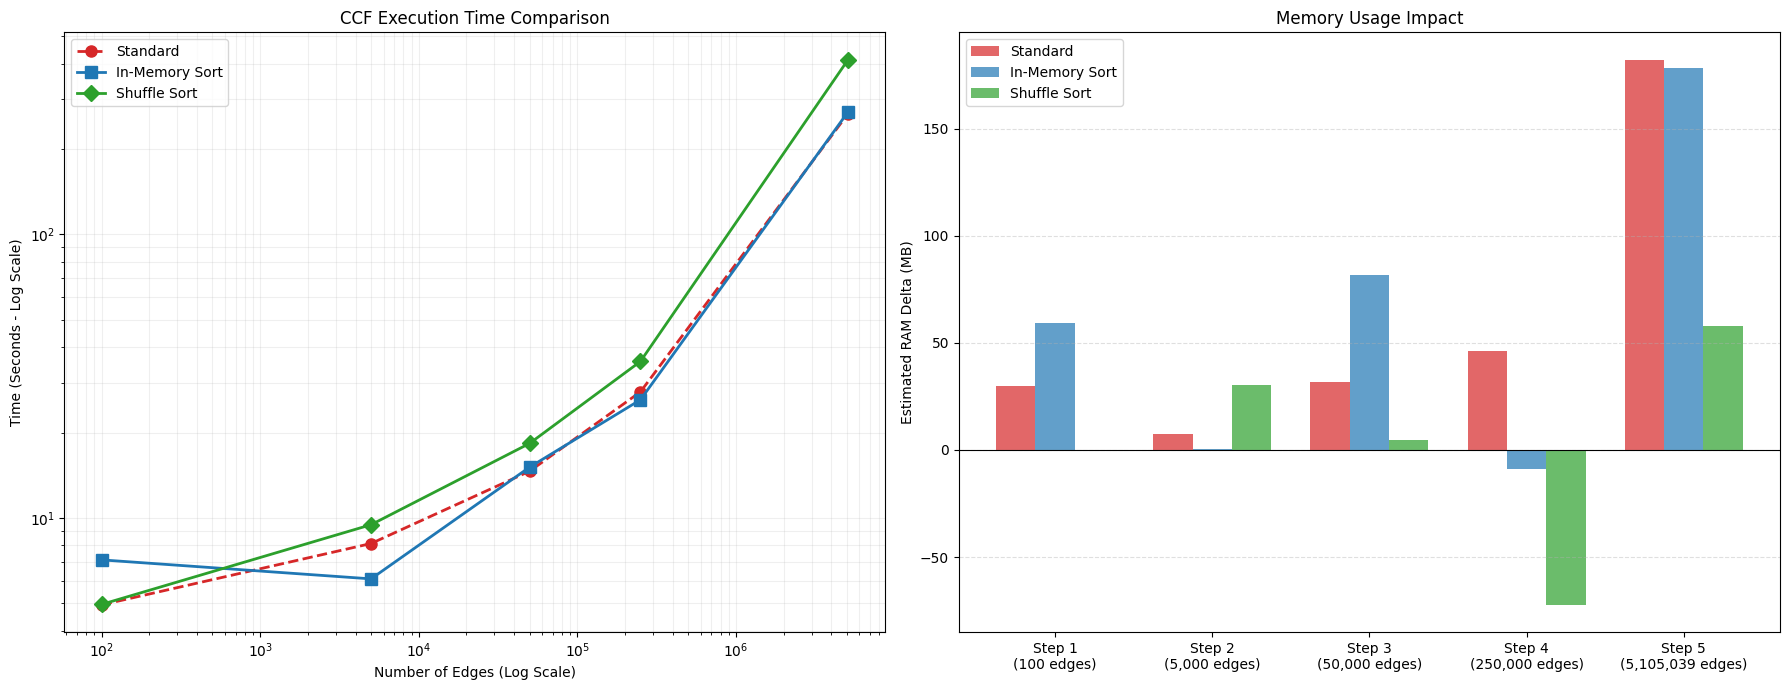

In [17]:
import matplotlib.pyplot as plt

def make_plots(data):
    # check if list is empty
    if not data:
        print("err: no data")
        return

    # get x axis values
    x_val = [i['edges'] for i in data]
    steps = [i['step'] for i in data]

    # plot settings
    m_info = [
        ('base', 'Standard', 'red', 'o--'),
        ('ss', 'In-Mem', 'blue', 's-'),
        ('shuffle', 'Shuffle', 'green', 'D-')
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # time plot (log scale)
    for k, name, c, m in m_info:
        y_val = [i.get(f"time_{k}", 0) for i in data]
        ax1.plot(x_val, y_val, m, label=name, color=c)

    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Edges')
    ax1.set_ylabel('Sec')
    ax1.set_title('Time log-log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # ram plot (bars)
    idx = range(len(steps))
    w = 0.2

    for n, (k, name, c, _) in enumerate(m_info):
        y_ram = [i.get(f"ram_{k}", 0) for i in data]
        # shift bars manually
        shift = (n - 1) * w
        ax2.bar([p + shift for p in idx], y_ram, width=w, label=name, color=c, alpha=0.6)

    ax2.set_xticks(idx)
    ax2.set_xticklabels([f"S{s}" for s in steps])
    ax2.set_ylabel('MB Delta')
    ax2.set_title('RAM impact')
    ax2.axhline(0, color='k', lw=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# call it
make_plots(results)

##v4

In [8]:
import time
import psutil
import gc
import os

def check_mem():
    # helper for ram tracking
    return psutil.virtual_memory().used / (1024 * 1024)

def fast_extract(f_path, n_lines):
    # use system pipe to avoid spark slowness on big gz
    tmp = "sub_data.txt"
    print(f"extacting {n_lines} lines...")
    os.system(f"zcat {f_path} | grep -v '^#' | head -n {n_lines} > {tmp}")

    # load small file into rdd
    rdd = sc.textFile(tmp)\
            .map(lambda l: l.replace('\t', ' ').split())\
            .map(lambda p: (int(p[0]), int(p[1])))\
            .cache()
    rdd.count() # force load
    return rdd

# setup
f_input = "/content/com-friendster.ungraph.txt.gz"
# scaling from 200k to 1M
steps_list = [200000, 400000, 600000, 800000, 1000000]
variants = [
    ("base", "Standard"),
    ("ss", "In-Memory"),
    ("shuffle", "Shuffle Sort")
]
results = []

for num in steps_list:
    print(f"\n>>> TESTING SCALE: {num} edges <<<")

    try:
        # fresh load for each scale to be clean
        data_rdd = fast_extract(f_input, num)
    except:
        print("load error")
        continue

    meta = {"step": num // 1000, "edges": num}

    for vid, vname in variants:
        print(f"running {vname}...")

        # cleanup before each run
        gc.collect()
        sc._jvm.System.gc()

        m1 = check_mem()
        t1 = time.time()

        try:
            # execute ccf logic
            _ = CCF.apply_CCF(data_rdd, mode=vid, skip_mapping=True)

            runtime = time.time() - t1
            m_diff = check_mem() - m1

            meta[f"time_{vid}"] = runtime
            meta[f"ram_{vid}"] = m_diff
            print(f"done {vid}: {runtime:.2f}s")

        except Exception as e:
            print(f"fail {vid}: {str(e)[:50]}")
            meta[f"time_{vid}"] = -1
            meta[f"ram_{vid}"] = 0

    results.append(meta)
    data_rdd.unpersist()

print("\nall tests done.")


>>> TESTING SCALE: 200000 edges <<<
extacting 200000 lines...
running Standard...
done base: 35.10s
running In-Memory...
done ss: 29.69s
running Shuffle Sort...
done shuffle: 39.95s

>>> TESTING SCALE: 400000 edges <<<
extacting 400000 lines...
running Standard...
done base: 50.29s
running In-Memory...
done ss: 52.81s
running Shuffle Sort...
done shuffle: 77.82s

>>> TESTING SCALE: 600000 edges <<<
extacting 600000 lines...
running Standard...
done base: 70.65s
running In-Memory...
done ss: 71.69s
running Shuffle Sort...
done shuffle: 103.00s

>>> TESTING SCALE: 800000 edges <<<
extacting 800000 lines...
running Standard...
done base: 90.82s
running In-Memory...
done ss: 89.92s
running Shuffle Sort...
done shuffle: 136.91s

>>> TESTING SCALE: 1000000 edges <<<
extacting 1000000 lines...
running Standard...
done base: 109.09s
running In-Memory...
done ss: 110.90s
running Shuffle Sort...
done shuffle: 171.63s

all tests done.


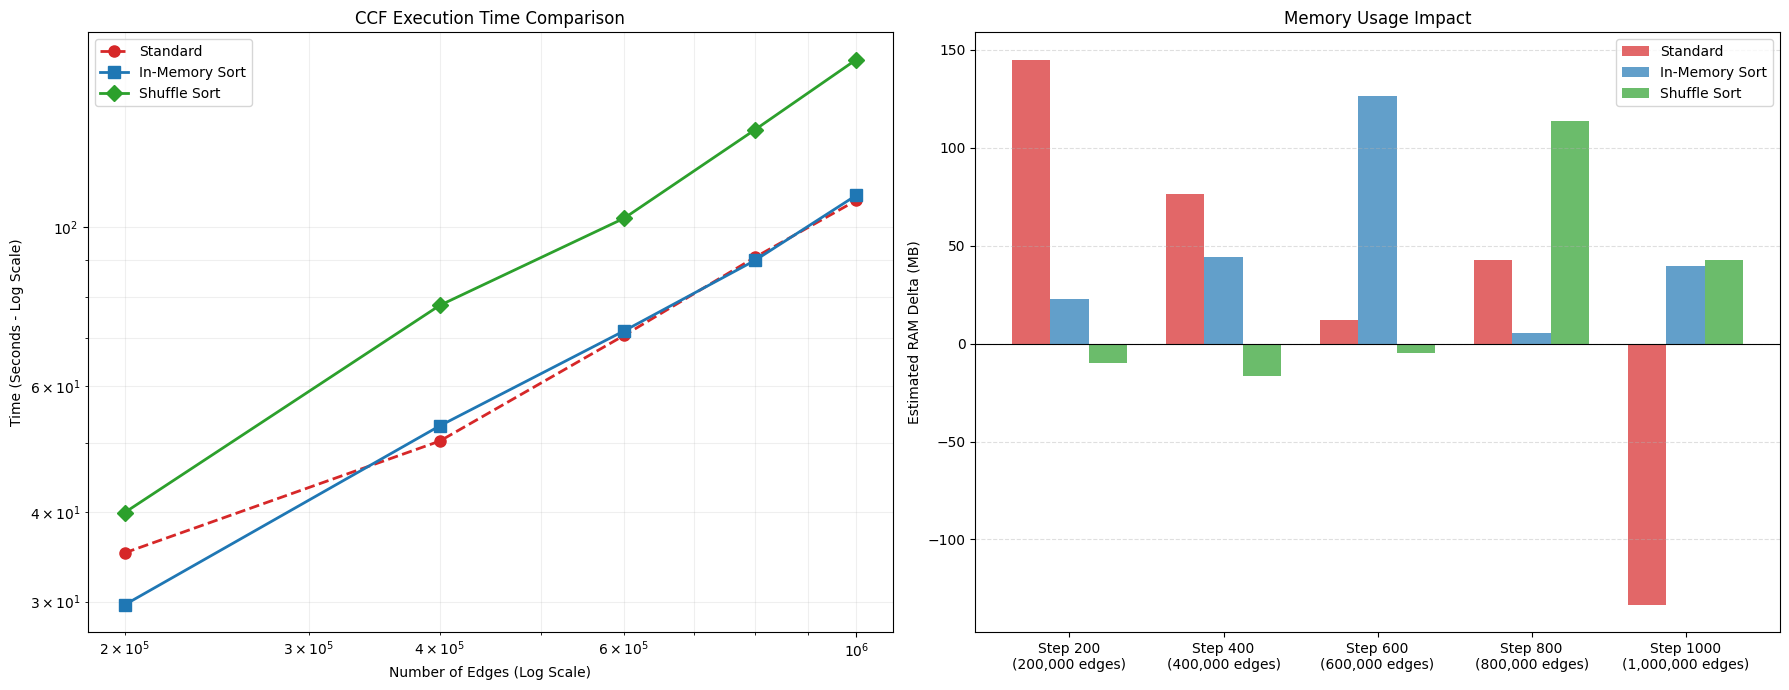

In [9]:
import matplotlib.pyplot as plt

def draw_perf_charts(data_list):
    # quick check
    if not data_list:
        print("nothing to show")
        return

    # axis data
    x_coords = [d['edges'] for d in data_list]
    idx = range(len(data_list))

    # viz settings (simple colors)
    cfg = [
        ('base', 'Standard', 'red', 'o--'),
        ('ss', 'In-Mem', 'blue', 's-'),
        ('shuffle', 'Shuffle', 'green', 'D-')
    ]

    plt.figure(figsize=(16, 6))

    # graph 1: time (log-log for scaling)
    plt.subplot(1, 2, 1)
    for k, name, c, m in cfg:
        y = [d.get(f"time_{k}", 0) for d in data_list]
        plt.plot(x_coords, y, m, label=name, color=c)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Edges (log)')
    plt.ylabel('Sec (log)')
    plt.title('Time Scaling')
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()

    # graph 2: memory delta
    plt.subplot(1, 2, 2)
    w = 0.2

    for i, (k, name, c, _) in enumerate(cfg):
        y_ram = [d.get(f"ram_{k}", 0) for d in data_list]
        # manual offset for bar groups
        pos = [p + (i - 1) * w for p in idx]
        plt.bar(pos, y_ram, width=w, label=name, color=c, alpha=0.6)

    # simple labels
    x_ticks = [f"Step {d['step']}" for d in data_list]
    plt.xticks(idx, x_ticks)
    plt.ylabel('MB (Delta)')
    plt.title('Memory impact')
    plt.axhline(0, color='black', lw=0.5)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# run viz
draw_perf_charts(results)